## Bank churn analysis

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [37]:
path = r'C:\Users
df = pd.read_csv(path)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
file = open(path)
print(file.read)

<built-in method read of _io.TextIOWrapper object at 0x000001C2B47225F0>


### Review data 

In [39]:
df.shape

(10000, 13)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [41]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [42]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
Exited,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


In [43]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Only about 20% of customers have churned. This shows that we are dealing with a class imbalanced classification program. Requires some feature engineering to create a balanced data set before predictive modelling. 

### EDA

In [44]:
numerical_vars = [
  'CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

categorical_vars = [
  'Gender', 'NumOfProducts', 'Geography', 'HasCrCard', 'IsActiveMember', 'Exited']


#### Categorical variables and churn

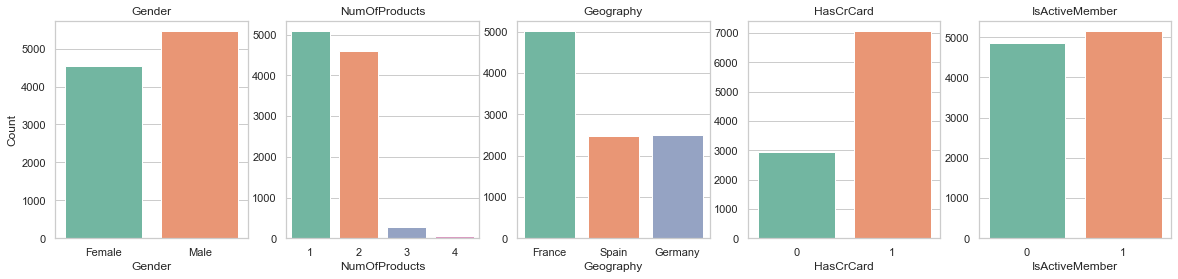

In [45]:
cols = ['Gender', 'NumOfProducts', 'Geography', 'HasCrCard', 'IsActiveMember']
category = cols

plt.figure(figsize=(20,4))

for i, col in enumerate(category):
    ax = plt.subplot(1, len(category), i+1)
    sns.countplot(x=str(col), data=df, palette = "Set2")
    ax.set_title(f"{col}")
    # Show y-axis label only on the first plot
    if i == 0:
        ax.set_ylabel("Count")
        
    else:
        ax.set_ylabel("")  # Remove y-axis label on other plots

There is about a 1000 more male customers than females. Most of the customers possess 1 or 2 products, reside in France and possess a credit card. There is an almost an equal amount of active and none active members. . 

Now lets analyse the relationships between our categorical variables and churn

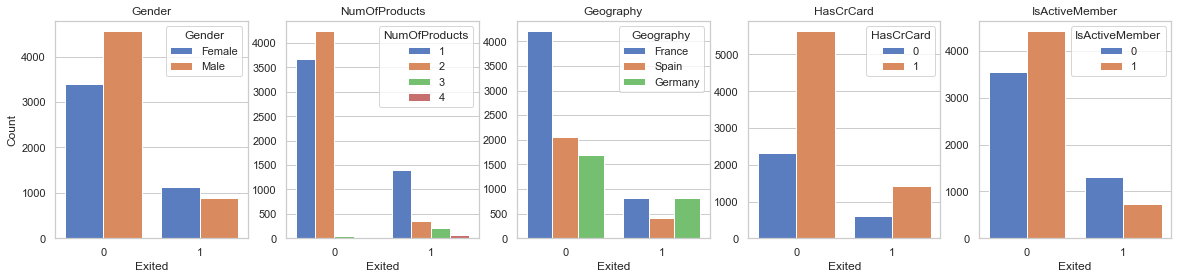

In [46]:
cols = ['Gender', 'NumOfProducts', 'Geography', 'HasCrCard', 'IsActiveMember']

plt.figure(figsize=(20,4))

for i, col in enumerate(cols):
    ax = plt.subplot(1, len(cols), i+1)
    sns.countplot(x = 'Exited', hue = str(col), data = df)
    ax.set_title(f"{col}")
# Show y-axis label only on the first plot
    if i == 0:
        ax.set_ylabel("Count")
        
    else:
        ax.set_ylabel("")  # Remove y-axis label on other plots

1. **Gender:** There were more female churners cmpared to males <br>
1. __Number of Products:__ Most churners had only one product with the bank
1. **Geography:** In comparion to France, Germany has the same number of churners despite having less numbers of customers from this country. It seems Spain retains more of its customers than other coutries
1. __Has a Credit card:__ Having a credit seems to have no impact on churning. Most of the churners possessed a credit card
1. __Is an Active Member:__ An active membership seems to deter customers from churning. A high nymber of churners were not active members. 

#### Numeric variables and churn 

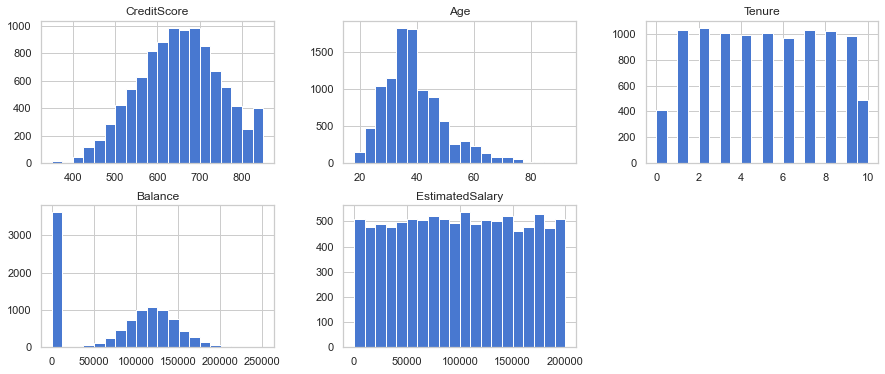

In [47]:
sns.set(style='whitegrid', palette="muted")

df[numerical_vars].hist(bins=20, figsize=(15, 6), layout=(2, 3));

CrediScore shows some normal distribution peaking between 600 and 700, whilst age is skewde to the left with most customers aged between 30 and 40 years. There is a large number of clients with a bank balance close to zero.   

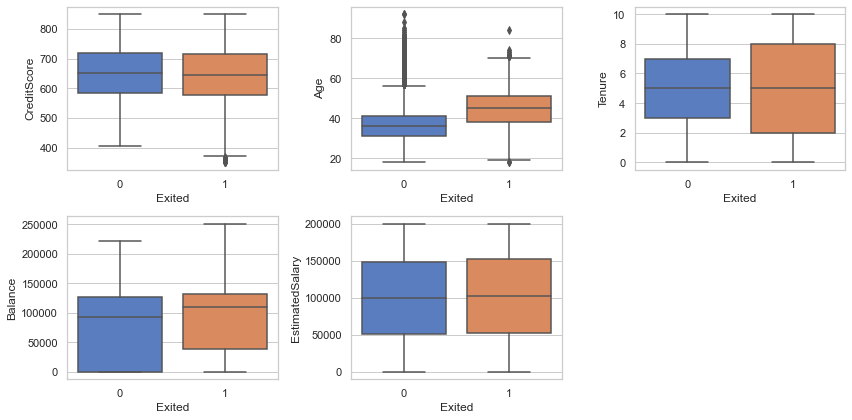

In [48]:
numerical_vars = [
  'CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

palette = sns.color_palette("Set2")
for var, subplot in zip(numerical_vars, ax.flatten()):
    sns.boxplot(x='Exited', y=var, data=df, ax=subplot, palette="muted");
    
# Turn off the unused 6th subplot
if len(numerical_vars) < len(ax.flatten()):
    ax.flatten()[len(numerical_vars)].axis('off')

plt.tight_layout()
plt.show();

1. __Credit Score:__ No difference in credit scores between curners and non churners
1. __Age:__ Overall age has an influnce on churn or leaving the bank. Most customers who churned were older, with median age about 45 years as compared to 35 in those who stayed. However there is wide age range in the non-churners as shown by the long tail of the boxplot
1. __Tenure:__ Is best analysed as a categorical variables. It ranges from 0 to 10 years. Though it seems there is a wide range in banking years from those who existed, we will conduct further analyses treating the variable as categorical
1. __Balance:__ The bank seems to lose customers with higher bank balances than those who are retained
1. __Estimated Salary:__ The plot shows no differences in salaries between churners and non churners. 

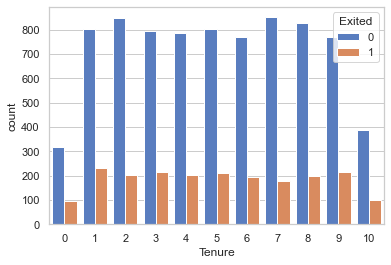

In [49]:
sns.countplot(x='Tenure', hue='Exited', data=df);

It seems there are no differences between thos who do not over the years. The least number of churners is in the first and 10th tenure. 

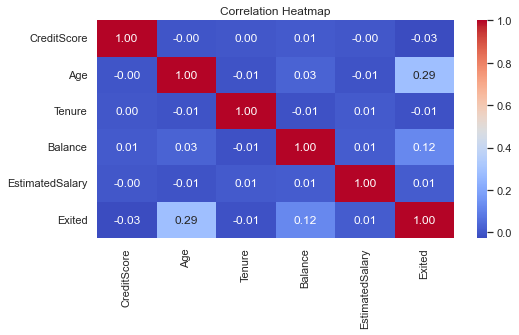

In [50]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Exited']].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

No apparent strong correlations between numerical variables

### Data Preprocessing 

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [52]:
final_df = df.drop(['Surname'], axis=1)
final_df .head(2)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [53]:
encoder=LabelEncoder()
col_list=['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'CustomerID']
for col in final_df.columns:
    if col not in  col_list:
        final_df[col]=encoder.fit_transform(final_df[col])

In [54]:
final_df.head(3)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2736,619,0,0,42,2,0.00,0,1,1,101348.88,1
1,3258,608,2,0,41,1,83807.86,0,0,1,112542.58,0
2,2104,502,0,0,42,8,159660.80,2,1,0,113931.57,1


In [55]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  int32  
 3   Gender           10000 non-null  int32  
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int32(2), int64(8)
memory usage: 859.5 KB


In [56]:
final_df = final_df.drop(['CustomerId'], axis=1)

X = final_df.drop(['Exited'], axis=1)
y = final_df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [57]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
9069,619,2,0,32,4,175406.13,1,1,1,172792.43
2603,643,1,0,34,7,160426.07,0,0,1,188533.11
7738,561,0,1,33,6,0.00,1,0,0,173680.39
1579,618,1,1,41,8,37702.79,0,1,1,195775.48
5058,714,0,1,37,9,148466.93,1,0,1,151280.96
...,...,...,...,...,...,...,...,...,...,...
5734,768,0,1,54,8,69712.74,0,1,1,69381.05
5191,682,0,0,58,1,0.00,0,1,1,706.50
5390,735,0,0,38,1,0.00,2,0,0,92220.12
860,667,0,1,43,8,190227.46,0,1,0,97508.04


In [58]:
y_train

9069    1
2603    0
7738    0
1579    0
5058    0
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: Exited, Length: 7000, dtype: int64

##### Over sampling to avoid class imbalance

In [59]:
#Oversampling the training set
from imblearn.over_sampling import SMOTE

oversample_data = SMOTE(k_neighbors=5)
X_smote, y_smote = oversample_data.fit_resample(X_train, y_train)
X_train, y_train = X_smote, y_smote

In [60]:
 #shapes of the datasets
print(f'Shape of X_train {X_train.shape}')
print(f'Shape of X_test {X_test.shape}')
print(f'Shape of y_train {y_train.shape}')
print(f'Shape of y_test {y_test.shape}')

Shape of X_train (11094, 10)
Shape of X_test (3000, 10)
Shape of y_train (11094,)
Shape of y_test (3000,)


In [61]:
y_train.value_counts()

Exited
1    5547
0    5547
Name: count, dtype: int64

In [62]:
models=[RandomForestClassifier(random_state=42), DecisionTreeClassifier(random_state=42), SVC(kernel='rbf', C=0.1)]
for model in models:
    cv_score=cross_val_score(model,X,y,cv=5)
    mean_score=(sum(cv_score)/len(cv_score))*100
    mean_score=round(mean_score,2)
    print(model,'   ',cv_score)
    print(model,' score',mean_score,'%')
    print('_____________________________________________________________')

RandomForestClassifier(random_state=42)     [0.8575 0.8685 0.86   0.868  0.8585]
RandomForestClassifier(random_state=42)  score 86.25 %
_____________________________________________________________
DecisionTreeClassifier(random_state=42)     [0.787  0.7995 0.7795 0.7775 0.7935]
DecisionTreeClassifier(random_state=42)  score 78.74 %
_____________________________________________________________
SVC(C=0.1)     [0.796  0.796  0.7965 0.7965 0.7965]
SVC(C=0.1)  score 79.63 %
_____________________________________________________________


In [63]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [64]:
from sklearn.metrics import accuracy_score

preds = rf.predict(X_test)
print(accuracy_score(preds,y_test))

0.817


In [65]:
preds=rf.predict(X_test)
print('Accuracy_Score =',round((accuracy_score(y_test,preds)*100),2),'%')
print('----------------------------------------------------')
print('confusion_matrix\n',confusion_matrix(y_test,preds))
print('----------------------------------------------------')
print('classification_report\n',classification_report(y_test,preds))

Accuracy_Score = 81.7 %
----------------------------------------------------
confusion_matrix
 [[2085  331]
 [ 218  366]]
----------------------------------------------------
classification_report
               precision    recall  f1-score   support

           0       0.91      0.86      0.88      2416
           1       0.53      0.63      0.57       584

    accuracy                           0.82      3000
   macro avg       0.72      0.74      0.73      3000
weighted avg       0.83      0.82      0.82      3000



**Our model is performing well, with an accuracy of approximately *81%* on the test dataset.**

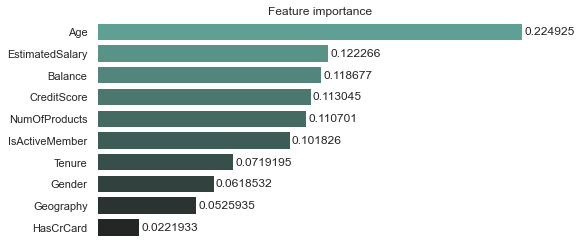

In [66]:
# Feature names and importance in DataFrame
feature_df = pd.DataFrame({'features': rf.feature_names_in_, 'importance': rf.feature_importances_ })
# Sorting data from highest to lowest
df_sorted = feature_df.sort_values(by='importance', ascending=False)

# Barplot of the result without borders and axis lines
plt.figure(figsize=(8, 4))
g = sns.barplot(data=df_sorted, x='importance', y ='features', palette="dark:#5A9_r");
sns.despine(bottom = True, left = True);
g.set_title('Feature importance');
g.set(xlabel=None)
g.set(ylabel=None)
g.set(xticks=[])
plt.savefig("clf_variable_importance.png", format="png", bbox_inches="tight", facecolor='w')
for value in g.containers:
    g.bar_label(value, padding=2)
plt.show();

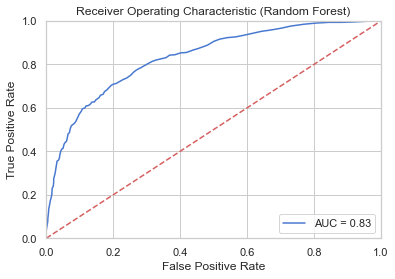

In [68]:
import sklearn.metrics as metrics
probs = rf.predict_proba(X_test)
ppreds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, ppreds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic (Random Forest)')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Applying logistic regression analysis

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df1 = df.drop(['Surname', 'CustomerId'], axis=1)

# Identify columns to scale and encode
columns_to_scale = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
columns_to_encode = ['Geography', 'Gender']


# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df1, columns=columns_to_encode, drop_first=True)

# Standard scaling for selected numerical columns
scaler = StandardScaler()
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

# Define features and target
X = df_encoded.drop(['Exited'], axis=1)
y = df_encoded['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print('Accuracy_Score =',round((accuracy_score(y_test, y_pred)*100),2),'%')
print('----------------------------------------------------')
print('confusion_matrix\n',confusion_matrix(y_test, y_pred))
print('----------------------------------------------------')
print('classification_report\n',classification_report(y_test, y_pred))

Accuracy_Score = 81.17 %
----------------------------------------------------
confusion_matrix
 [[2319   97]
 [ 468  116]]
----------------------------------------------------
classification_report
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      2416
           1       0.54      0.20      0.29       584

    accuracy                           0.81      3000
   macro avg       0.69      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



In [70]:
feature_names = X_train.columns.values

summary_table = pd.DataFrame(columns=['feature name'],data=feature_names) 

summary_table['Coefficient'] = model.coef_.T

summary_table.index = summary_table.index +1

summary_table.loc[0] = ['Intercept',model.intercept_[0]]

summary_table = summary_table.sort_index()

summary_table['Odds ratio'] = np.exp(summary_table.Coefficient)

summary_table.sort_values('Odds ratio',ascending=False)

,feature name,Coefficient,Odds ratio
9,Geography_Germany,0.768594,2.156731
2,Age,0.745651,2.107812
4,Balance,0.172140,1.187844
10,Geography_Spain,0.086810,1.090689
8,EstimatedSalary,0.004404,1.004414
3,Tenure,-0.021510,0.978719
6,HasCrCard,-0.064213,0.937805
5,NumOfProducts,-0.074429,0.928273
1,CreditScore,-0.075807,0.926995
11,Gender_Male,-0.529829,0.588706


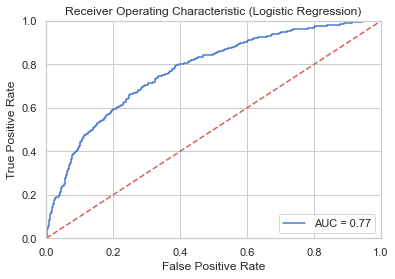

In [73]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_test)
ppreds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, ppreds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic (Logistic Regression)')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


*** End ***